<a href="https://colab.research.google.com/github/AndrewLoweUoM/Hydrological_Analysis/blob/main/Data_Preparation_Checking_Events_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code

This script performs event-based hydrological analysis on multiple storm events stored in a wide-format dataset, including:

* Visualising individual and multiple hydrographs
* Aligning events to rainfall onset
* Comparing event responses
* Calculating event durations
* Statistical analysis of duration
* Seasonal classification

# Data Loading & Exploration

* Loads a wide-format CSV (multi-event, column-based):
   * Event001_Time, Event001_Flow, Event001_Rain,
* Each event is stored as a separate set of columns.

* Checks:
  * Shape, columns
  * Head/tail preview
  * Missing values and stats are present

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all event data
file_path='/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Oak_Rain_Flow_Events 2023_2024_SingleQ_edited.csv'
#file_path ='/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Oak_Rain_Flow_Events 2023_2024_SingleQ.csv'
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Oak_Rain_Flow_Events 2023_2024.csv'
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/storm_event_timeseries_all_wide_v5.csv'
# Load the all event data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Bollin_storm_event_timeseries_all_wide_v3_before.csv'
# Load the all event data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/_Bollin_storm_event_timeseries_all_wide_v3_after.csv'

df_events = pd.read_csv(file_path)
# Displays start data in the Dataframe
df_events.head()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:00,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 09:15,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 09:30,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 09:45,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:00,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


### Display DataFrame Dimensions, Check Missing Values, and Describe Statistics

In [ ]:
# Displays end data in the Dataframe
df_events.tail()

,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event037_Flow,Event037_Baseflow,Event038_Time,Event038_Rain,Event038_Flow,Event038_Baseflow,Event039_Time,Event039_Rain,Event039_Flow,Event039_Baseflow
601,602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
602,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display summary of the DataFrame
print(df_events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 89 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               606 non-null    int64  
 1   Event001_Time      231 non-null    object 
 2   Event001_Rain      231 non-null    float64
 3   Event001_Flow      231 non-null    float64
 4   Event001_Baseflow  231 non-null    float64
 5   Event002_Time      207 non-null    object 
 6   Event002_Rain      207 non-null    float64
 7   Event002_Flow      207 non-null    float64
 8   Event002_Baseflow  207 non-null    float64
 9   Event003_Time      162 non-null    object 
 10  Event003_Rain      162 non-null    float64
 11  Event003_Flow      162 non-null    float64
 12  Event003_Baseflow  162 non-null    float64
 13  Event004_Time      125 non-null    object 
 14  Event004_Rain      125 non-null    float64
 15  Event004_Flow      125 non-null    float64
 16  Event004_Baseflow  125 non

In [ ]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df_events.shape)

Shape of data: (606, 89)


In [ ]:
# Displays all columnns in the DataFrame
print(df_events.columns)

Index(['Time', 'Event001_Time', 'Event001_Rain', 'Event001_Flow',
       'Event001_Baseflow', 'Event002_Time', 'Event002_Rain', 'Event002_Flow',
       'Event002_Baseflow', 'Event003_Time', 'Event003_Rain', 'Event003_Flow',
       'Event003_Baseflow', 'Event004_Time', 'Event004_Rain', 'Event004_Flow',
       'Event004_Baseflow', 'Event005_Time', 'Event005_Rain', 'Event005_Flow',
       'Event005_Baseflow', 'Event006_Time', 'Event006_Rain', 'Event006_Flow',
       'Event006_Baseflow', 'Event007_Time', 'Event007_Rain', 'Event007_Flow',
       'Event007_Baseflow', 'Event008_Time', 'Event008_Rain', 'Event008_Flow',
       'Event008_Baseflow', 'Event009_Time', 'Event009_Rain', 'Event009_Flow',
       'Event009_Baseflow', 'Event010_Time', 'Event010_Rain', 'Event010_Flow',
       'Event010_Baseflow', 'Event011_Time', 'Event011_Rain', 'Event011_Flow',
       'Event011_Baseflow', 'Event012_Time', 'Event012_Rain', 'Event012_Flow',
       'Event012_Baseflow', 'Event013_Time', 'Event013_Rain', 'Ev

In [ ]:
# Check for missing values in the DataFrame
print(df_events.isnull().sum())

Time                   0
Event001_Time        375
Event001_Rain        375
Event001_Flow        375
Event001_Baseflow    375
                    ... 
Event021_Baseflow    300
Event022_Time        350
Event022_Rain        350
Event022_Flow        350
Event022_Baseflow    350
Length: 89, dtype: int64


In [ ]:
#replace null values with 0
#df_events.fillna(0, inplace=True)
#df_events.fillna(method='ffill', inplace=True)

In [ ]:
# Display summary statistics of the DataFrame
#print(df_events.describe())

### Specify the Number of Flood Hydrograph Events

In [ ]:
# Number of flood hydrograph events
#N = 39
N = 23
#timestep in minutes
T=15
time_unit=60/T

In [ ]:
# define varables
date=df_events['Event003_Time']
flow=df_events['Event003_Flow']
rain=df_events['Event003_Rain']

# Single Event Hydrograph Plot



### Plot Selected Single Event Hydrograph & Rainfall

Extracts one event (e.g. Event002)

Plots:
* Flow (line)
* Rainfall (bars)

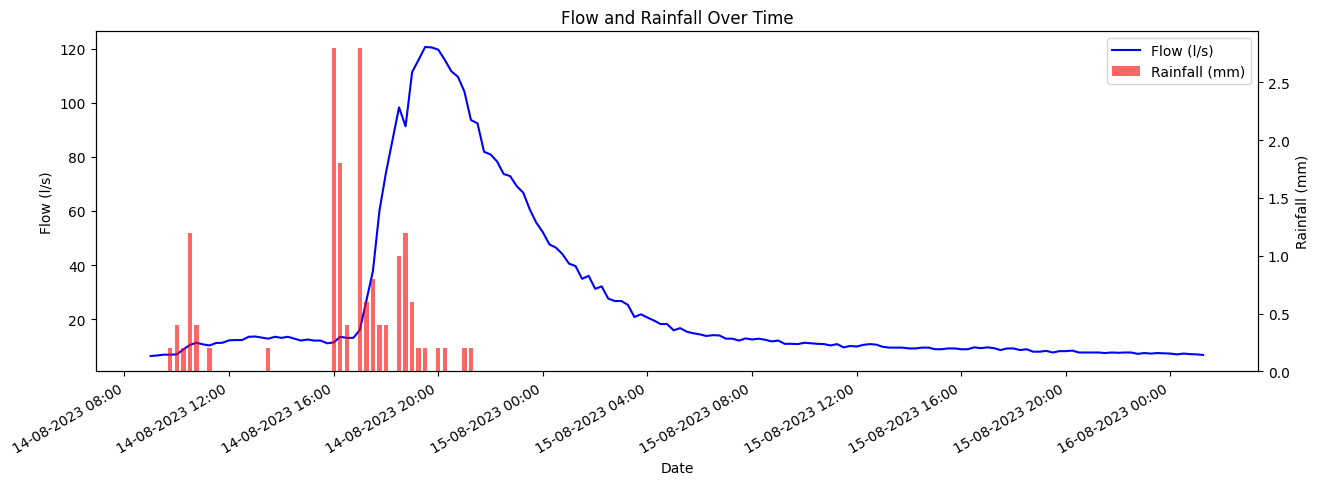

In [ ]:
# Ensure 'Event_Time' is in datetime format for proper plotting
datetime = pd.to_datetime(date, errors='coerce', dayfirst=True)

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(15, 5))

# Plot 'Flow' on the first y-axis
ax1.plot(datetime, flow, color='blue', label='Flow (l/s)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (l/s)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()
# Plot 'Rain' on the second y-axis as bars
ax2.bar(datetime, rain, color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(minutes=10))
ax2.set_ylabel('Rainfall (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set title and add legends
plt.title('Flow and Rainfall Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Set x-axis date format to show full date and time
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)

# Improve date formatting on x-axis
fig.autofmt_xdate()

plt.show()

# Multi-Event Hydrograph Plot



Plots multiple hydrograps:

*  By looping through 'N' events
* Dynamically constructing column names

In order to compare hydrograph shapes across events


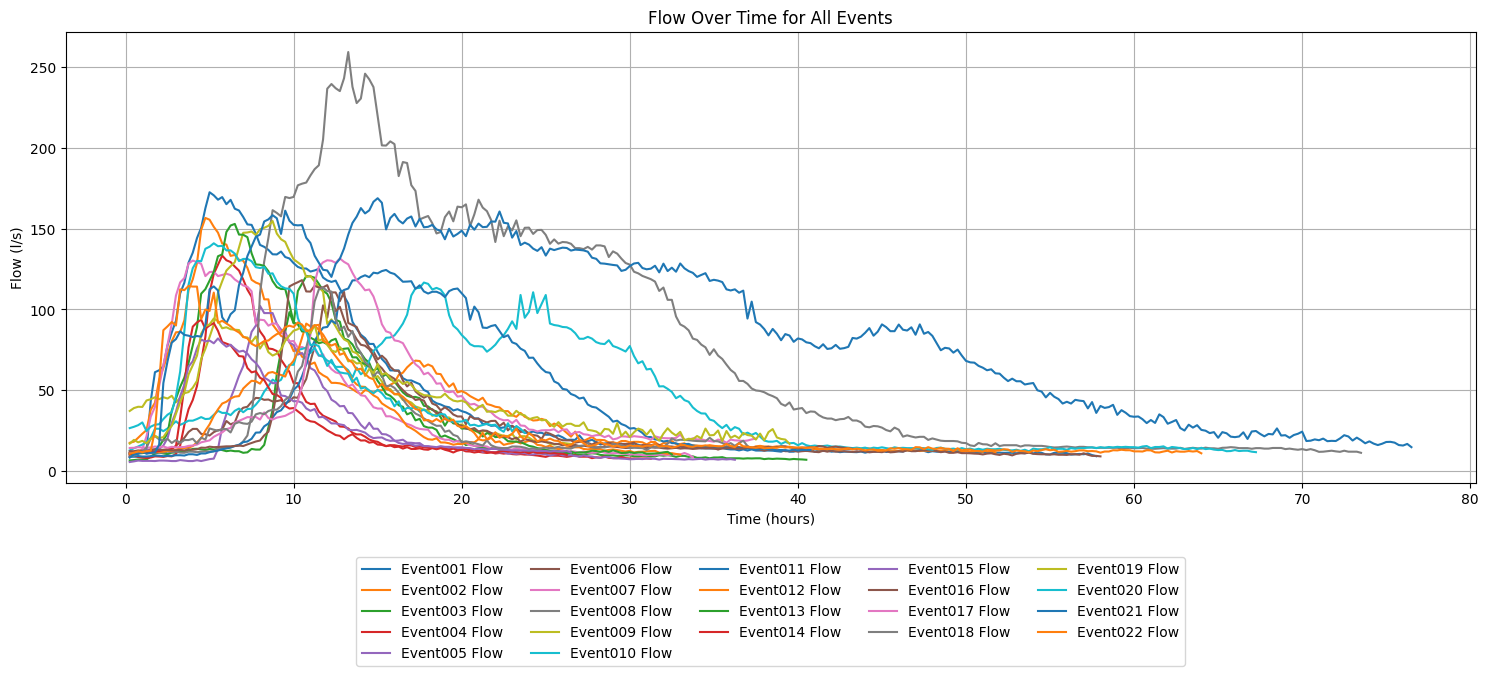

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axes for the plot and plots all flow series together
fig, ax = plt.subplots(figsize=(15, 7))

# Loop through all 'N' events and plot their flow data, and dynamically constructing column names: Event{i:03d}_Flow
for i in range(1, N):
    flow_col_name = f'Event{i:03d}_Flow'

    # Check if the column exists in df_events and has valid data (Time is a time index and is divided by 4 to get hours)
    if flow_col_name in df_events.columns and not df_events[flow_col_name].isnull().all():
        ax.plot(df_events['Time']/time_unit, df_events[flow_col_name], label=f'Event{i:03d} Flow')


# Set labels and title for the plot
# Time Index is the units of 15 minutes (divide by 4 to get hours)
#ax.set_xlabel('Time (index)')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flow (l/s)')
ax.set_title('Flow Over Time for All Events')

# Add a legend to differentiate the events
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

plt.grid(True)
plt.tight_layout()
plt.show()

# Event Alignment



### Adjust hydrographs to start at first recorded rainfall

Align all events to start at first rainfall. Key steps:

For each event:
* Find first index where:
   * Rain > 0

* Trim:
   * Rain
   * Flow
   * Time

* Reset index to start from 0
* Store in new dataframe (df_adjusted)
* Create unified time axis

All events aligned to t = 0 (rainfall onset)

In [ ]:
import pandas as pd
import numpy as np

# Create a copy for the adjusted data
df_events_adjusted = df_events.copy()

#print("Adjusting event starts to first recorded rainfall...")

for i in range(1, N):
    rain_col = f'Event{i:03d}_Rain'
    flow_col = f'Event{i:03d}_Flow'
    time_col = f'Event{i:03d}_Time'

    if rain_col in df_events.columns and not df_events[rain_col].isnull().all():
        # Find indices where rain > 0
        rain_indices = df_events.index[df_events[rain_col] > 0].tolist()

        if rain_indices:
            first_rain_idx = rain_indices[0]

            # Extract the data from first rain onwards
            subset_rain = df_events.loc[first_rain_idx:, rain_col].reset_index(drop=True)
            subset_flow = df_events.loc[first_rain_idx:, flow_col].reset_index(drop=True)
            subset_time = df_events.loc[first_rain_idx:, time_col].reset_index(drop=True)

            # Clear the old data in the adjusted dataframe
            df_events_adjusted[rain_col] = np.nan
            df_events_adjusted[flow_col] = np.nan
            df_events_adjusted[time_col] = np.nan

            # Explicitly cast the time column to object dtype before assignment to avoid FutureWarning
            df_events_adjusted[time_col] = df_events_adjusted[time_col].astype(object)

            # Place the trimmed data back starting at index 0
            df_events_adjusted.loc[:len(subset_rain)-1, rain_col] = subset_rain.values
            df_events_adjusted.loc[:len(subset_flow)-1, flow_col] = subset_flow.values
            df_events_adjusted.loc[:len(subset_time)-1, time_col] = subset_time.values

# Update the global 'Time' index to reflect relative steps if needed
df_events_adjusted['Time'] = range(1, len(df_events_adjusted) + 1)

#print("Adjustment complete. Displaying head of Event001 as example (starting at first rain):")
print(df_events_adjusted[['Time', 'Event001_Time', 'Event001_Rain', 'Event001_Flow']].head(5))

   Time     Event001_Time  Event001_Rain  Event001_Flow
0     1  26/07/2023 20:30            1.4           11.0
1     2  26/07/2023 20:45            1.6           11.6
2     3  26/07/2023 21:00            1.2           11.9
3     4  26/07/2023 21:15            0.8           12.0
4     5  26/07/2023 21:30            0.4           12.6


# Plot Adjusted Events


### Flow Comparison


Compare event response timing and magnitude:

* Plots all adjusted flows vs relative time
* Removes legend clutter (label='_nolegend_')

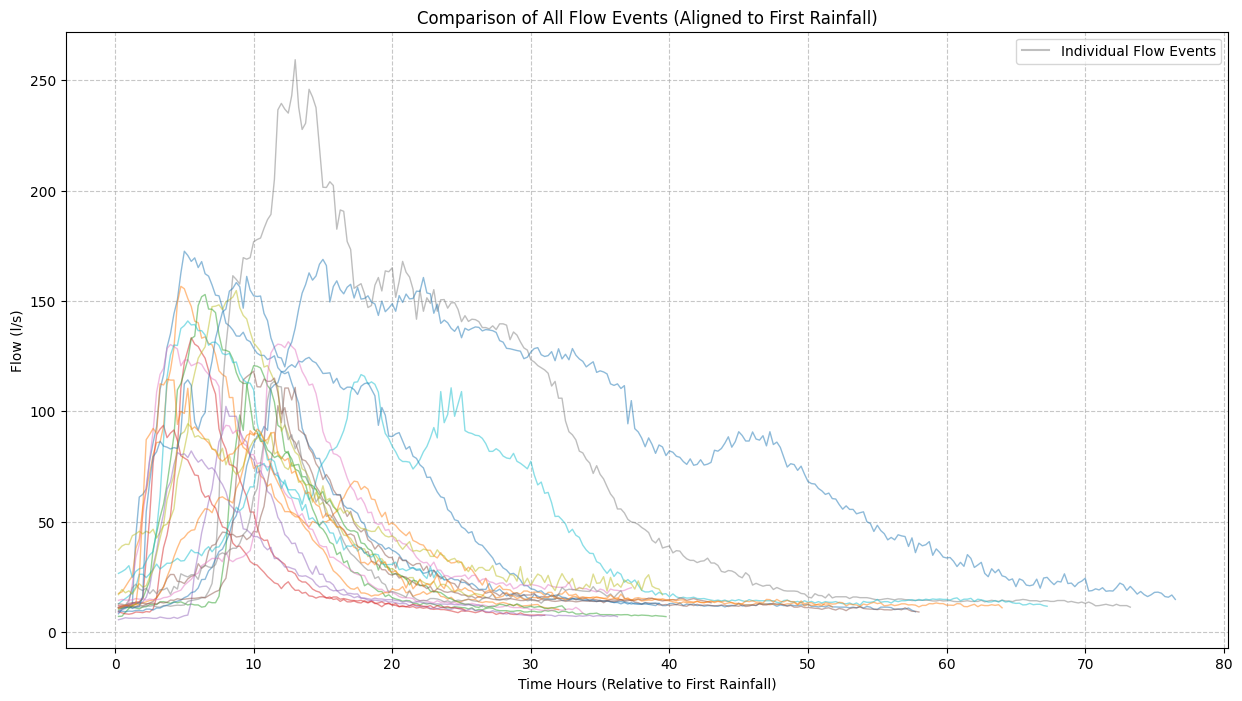

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events_adjusted.columns if col.endswith('_Flow')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain (Time is a time index and is divided by 4 to get hours)
    plt.plot(df_events_adjusted['Time'] / 4, df_events_adjusted[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
# Time Index is the units of 15 minutes (divide by 4 to get hours)
#plt.xlabel('Time Index (Relative to First Rainfall)')
plt.xlabel('Time Hours (Relative to First Rainfall)')
plt.ylabel('Flow (l/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual Flow Events')
plt.legend()

plt.show()

### Rainfall Comparison


Compare event response timing and magnitude:

* Plots all adjusted rainfall as an overlapping bar chart vs relative time
* Removes legend clutter (label='_nolegend_')

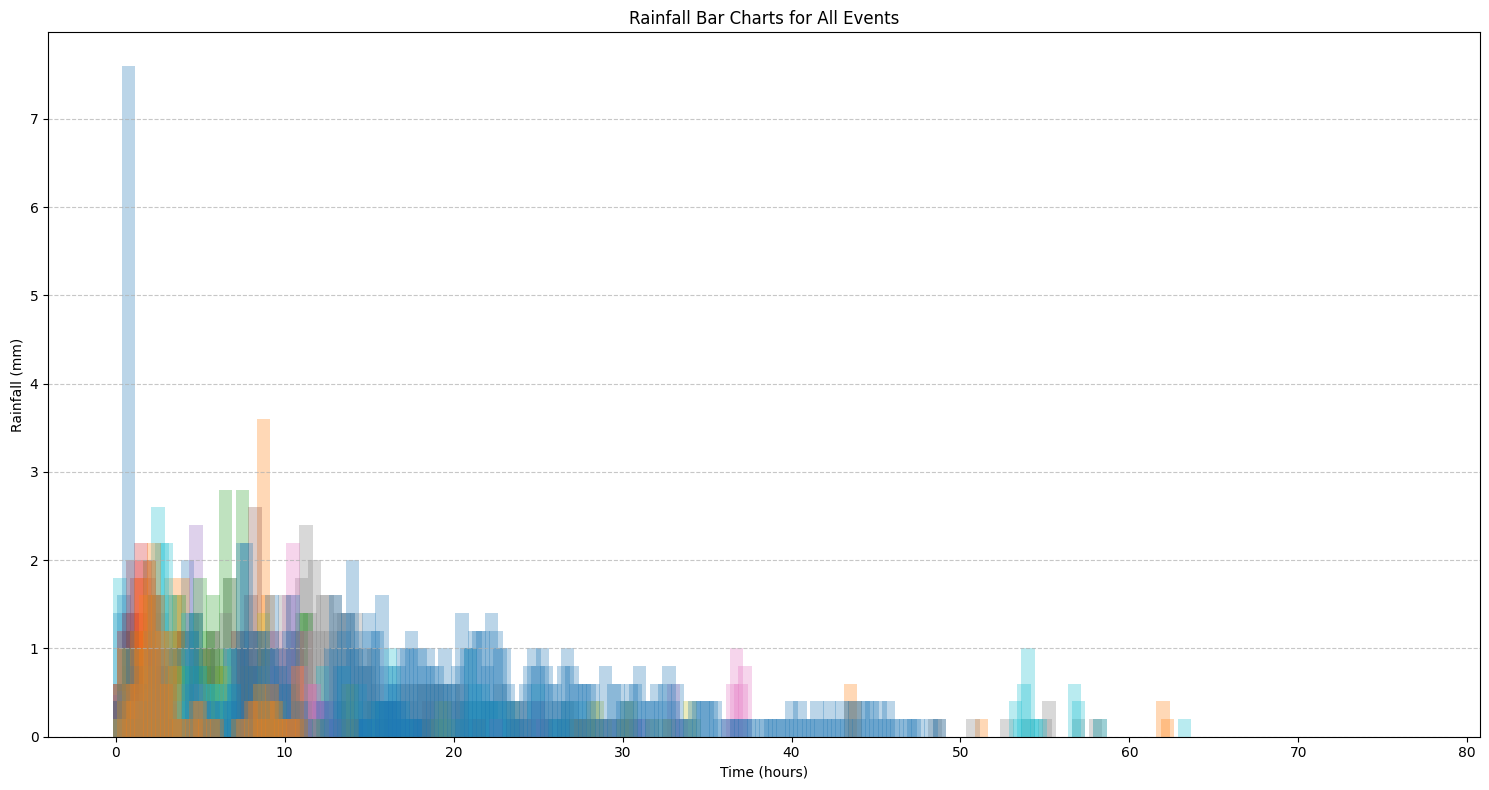

In [ ]:
import matplotlib.pyplot as plt

# Filter for rainfall columns
rain_columns = [col for col in df_events_adjusted.columns if col.endswith('_Rain')]

# Create a figure
plt.figure(figsize=(15, 8))

# Loop through and plot each event's rainfall as a bar chart whereas Time is a time index and is divided by 4 to get hours
for col in rain_columns:
    plt.bar(df_events_adjusted['Time'] / 4, df_events_adjusted[col], alpha=0.3, label='_nolegend_')

plt.title('Rainfall Bar Charts for All Events')
# plt.xlabel('Time (index)')
plt.xlabel('Time (hours)')
plt.ylabel('Rainfall (mm)')
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Save Adjusted Dataset

Exports aligned dataset:


In [ ]:
# Define the event output file path for the complete event analysis for all events
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Oak_storm_event_timeseries_23_events_adjusted.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted.csv'
# Define the event output file path for the complete event analysis for events before NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_before_events_adjusted.csv'
# Define the event output file path for the complete event analysis for events after NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_after_events_adjusted.csv'

# Save the adjusted event_peak_df to CSV
df_events_adjusted.to_csv(final_output_path, index=False)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Oak_storm_event_timeseries_23_events_adjusted.csv


# Validation Plot

### Replots a single adjusted event

Confirms:
* Event starts at rainfall onset (e.g. event001)

i.e. checks adjusting of event starts at the first recorded rainfall by selecting individual event

In [ ]:
# define varables
date=df_events_adjusted['Event013_Time']
flow=df_events_adjusted['Event013_Flow']
rain=df_events_adjusted['Event013_Rain']
time=df_events_adjusted['Time']

### Plot single adjusted event starts at first recorded rainfal

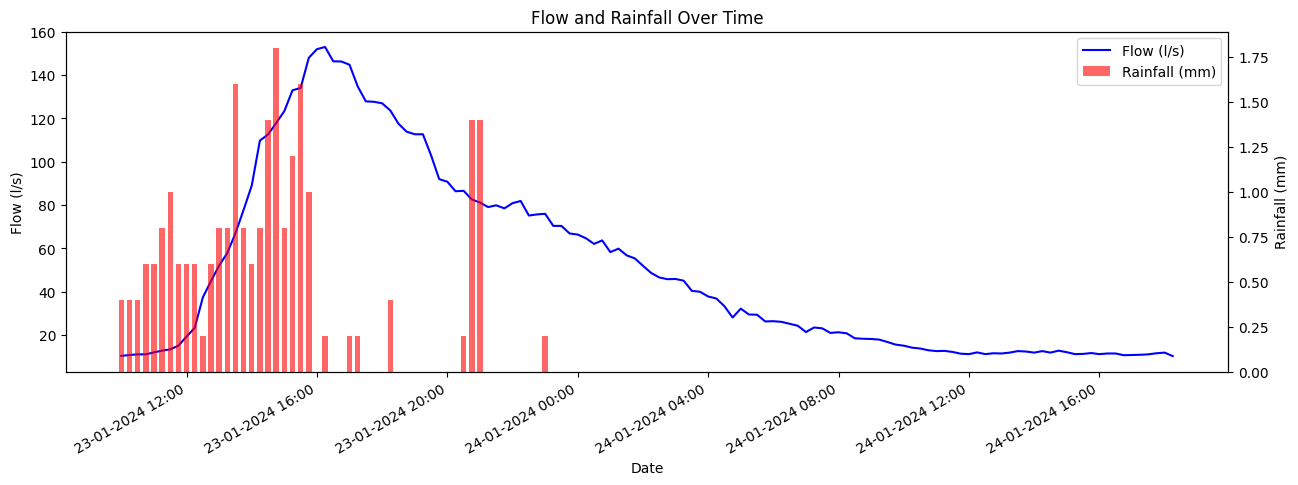

In [ ]:
# Ensure 'Event_Time' is in datetime format for proper plotting
datetime = pd.to_datetime(date, errors='coerce', dayfirst=True)

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(15, 5))

# Plot 'Flow' on the first y-axis
ax1.plot(datetime, flow, color='blue', label='Flow (l/s)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (l/s)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()
# Plot 'Rain' on the second y-axis as bars
ax2.bar(datetime, rain, color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(minutes=10))
ax2.set_ylabel('Rainfall (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set title and add legends
plt.title('Flow and Rainfall Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Set x-axis date format to show full date and time
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)

# Improve date formatting on x-axis
fig.autofmt_xdate()

plt.show()

# Event Duration Analysis

### Check the durations of all flow events.

For each event:
* Converts time column to datetime
* Computes:
  * Start time
  * End time
  * Duration (hours)
* Stores results in `duration_df`
* Outputs:
  * Table of event durations
  * CSV export



In [ ]:
import pandas as pd

# List to store duration data
event_durations = []

# Loop through all events potential events
for i in range(1, 54):
    date_col = f'Event{i:03d}_Time'

    if date_col in df_events.columns:
        # Convert to datetime and drop NaNs
        times = pd.to_datetime(df_events[date_col], errors='coerce', dayfirst=True).dropna()

        if not times.empty:
            start_time = times.min()
            end_time = times.max()
            duration = end_time - start_time
            duration_hours = duration.total_seconds() / 3600

            event_durations.append({
                'Event': f'Event{i:03d}',
                'Start Time': start_time,
                'End Time': end_time,
                'Duration (hours)': round(duration_hours, 2)
            })

# Create a DataFrame for the results
duration_df = pd.DataFrame(event_durations)

print("Storm Event Durations Summary:")
display(duration_df.head(5))

mean_duration = duration_df['Duration (hours)'].mean()
print(f"Mean Duration: {mean_duration:.2f} hours")

# Save the updated analysis results for all events
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Oak_duration_analysis_results_with_duration_23_events.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_duration_analysis_results_with_duration.csv'
# Save the updated analysis results for all events before NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_duration_analysis_results_with_duration_before.csv'
# Save the updated analysis results for all events after NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_duration_analysis_results_with_duration_after.csv'

duration_df.to_csv(final_output_path, index=False)

print(f'\nUpdated results saved to: {final_output_path}')

print(f'Successfully saved event adjusted results to: {final_output_path}')

Storm Event Durations Summary:


,Event,Start Time,End Time,Duration (hours)
0,Event001,2023-07-26 20:30:00,2023-07-29 06:00:00,57.50
1,Event002,2023-08-02 03:15:00,2023-08-04 06:45:00,51.50
2,Event003,2023-08-14 09:00:00,2023-08-16 01:15:00,40.25
3,Event004,2023-08-25 22:00:00,2023-08-27 05:00:00,31.00
4,Event005,2023-09-12 01:30:00,2023-09-13 13:30:00,36.00


Mean Duration: 43.27 hours

Updated results saved to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Oak_duration_analysis_results_with_duration_23_events.csv
Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Oak_duration_analysis_results_with_duration_23_events.csv


# Duration Distribution Analysis

Purpose to check extreme events beyond 95th percentile to consider removal

### Plot historgram of event duration and add 95th percentile

* Statistical Analysis:
  * Fits normal distribution

* Calculates:
  * Mean (μ)
  * Standard deviation (σ)
  * 95th percentile

* Visualisation:
  * Histogram
  * Normal curve
  * 95th percentile threshold

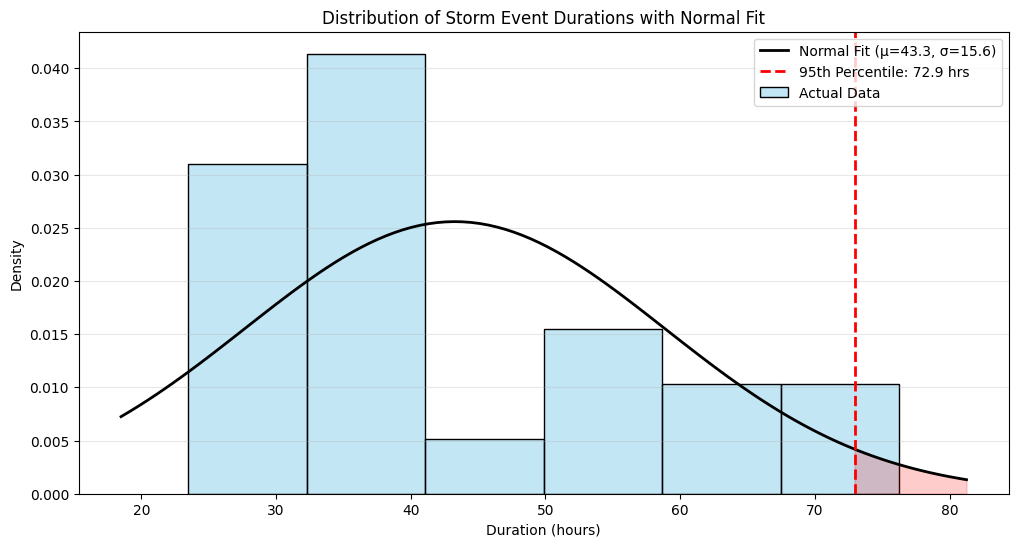

Mean Duration: 43.27 hours
Standard Deviation: 15.60 hours
95% of events are shorter than 72.94 hours


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

# Prepare data
durations = duration_df['Duration (hours)'].dropna()
mu, std = norm.fit(durations)

# Calculate the 95th percentile (empirical and theoretical)
p95_empirical = np.percentile(durations, 95)
p95_theoretical = norm.ppf(0.95, mu, std)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot histogram
sns.histplot(durations, kde=False, stat="density", color='skyblue', alpha=0.5, label='Actual Data')

# Plot Normal Distribution Curve
x = np.linspace(durations.min() - 5, durations.max() + 5, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit (μ={mu:.1f}, σ={std:.1f})')

# Add 95th Percentile line
plt.axvline(p95_empirical, color='red', linestyle='--', linewidth=2, label=f'95th Percentile: {p95_empirical:.1f} hrs')

# Fill area above 95th
x_tail = np.linspace(p95_empirical, x.max(), 100)
plt.fill_between(x_tail, norm.pdf(x_tail, mu, std), color='red', alpha=0.2)

# Formatting
plt.title('Distribution of Storm Event Durations with Normal Fit')
plt.xlabel('Duration (hours)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"Mean Duration: {mu:.2f} hours")
print(f"Standard Deviation: {std:.2f} hours")
print(f"95% of events are shorter than {p95_empirical:.2f} hours")

# Split Adjusted Events to Winter and Summer Events

### Categorise Events into Summer and Winter using the DataFrame `duration_df`

In [ ]:
import pandas as pd

# Ensure duration_df exists in globals
if 'duration_df' in globals():
    # Make a copy to avoid SettingWithCopyWarning if duration_df was a slice
    events_summary_df = duration_df.copy()

    # Convert 'Start Time' to datetime for seasonal logic
    events_summary_df['Start Time'] = pd.to_datetime(events_summary_df['Start Time'])

    # Winter Season: Oct (10), Nov (11), Dec (12), Jan (1), Feb (2), Mar (3)
    # Note: April 1 is included in Summer Season as per request

    def get_season(dt):
        if dt.month >= 10 or dt.month < 4 or (dt.month == 4 and dt.day == 1):
            return 'Winter'
        else:
            return 'Summer'

    # Apply seasonal categorization to the events_summary_df
    events_summary_df['Season'] = events_summary_df['Start Time'].apply(get_season)

    # Create Winter and Summer dataframes from the events_summary_df
    winter_season_df = events_summary_df[events_summary_df['Season'] == 'Winter'].copy()
    summer_season_df = events_summary_df[events_summary_df['Season'] == 'Summer'].copy()

    # Define paths
    winter_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_winter_season_events_flags_23events.csv'
    summer_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_summer_season_events_flags_23events.csv'

    #winter_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_winter_season_events_flags.csv'
    #summer_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_summer_season_events_flags.csv'

    # Save files
    winter_season_df.to_csv(winter_path, index=False)
    summer_season_df.to_csv(summer_path, index=False)

    print(f"Winter Season events identified: {len(winter_season_df)}")
    print(f"summer Season events identified: {len(summer_season_df)}")

    print(f"Saved Wet Season data to: {winter_path}")
    print(f"Saved Dry Season data to: {summer_path}")

    print('\nWinter Season DataFrame Head:')
    display(winter_season_df.head())

    print('\nSummer Season DataFrame Head:')
    display(summer_season_df.head())
else:
    print("Error: Required dataframe 'duration_df' not found in memory.")

Winter Season events identified: 12
summer Season events identified: 10
Saved Wet Season data to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_winter_season_events_flags_23events.csv
Saved Dry Season data to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_summer_season_events_flags_23events.csv

Winter Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
5,Event006,2023-10-05 19:00:00,2023-10-08 04:45:00,57.75,Winter
6,Event007,2023-10-13 03:00:00,2023-10-14 12:30:00,33.50,Winter
7,Event008,2023-10-19 22:00:00,2023-10-22 23:15:00,73.25,Winter
8,Event009,2023-11-02 09:45:00,2023-11-03 12:15:00,26.50,Winter
9,Event010,2023-11-14 18:00:00,2023-11-17 13:00:00,67.00,Winter



Summer Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
0,Event001,2023-07-26 20:30:00,2023-07-29 06:00:00,57.50,Summer
1,Event002,2023-08-02 03:15:00,2023-08-04 06:45:00,51.50,Summer
2,Event003,2023-08-14 09:00:00,2023-08-16 01:15:00,40.25,Summer
3,Event004,2023-08-25 22:00:00,2023-08-27 05:00:00,31.00,Summer
4,Event005,2023-09-12 01:30:00,2023-09-13 13:30:00,36.00,Summer


### Create New DataFrames for Winter and Summer Events

In [ ]:
# Get the list of event names for winter and summer seasons
winter_events = winter_season_df['Event'].tolist()
summer_events = summer_season_df['Event'].tolist()

# Prepare column lists for winter and summer clipped dataframes
# Start with the 'Time' index column
winter_cols = ['Time']
summer_cols = ['Time']

# Iterate through all columns in df_events_adjusted to find event-specific columns
for col in df_events_adjusted.columns:
    # Extract the event identifier (e.g., 'Event001') from the column name
    # This assumes column names are like 'EventXXX_Type'
    if '_' in col:
        event_id = col.split('_')[0]
    else:
        # Skip 'Time' column as it's already added
        continue

    if event_id in winter_events:
        winter_cols.append(col)
    elif event_id in summer_events:
        summer_cols.append(col)

# Create the new DataFrames by selecting the identified columns
# Use .copy() to ensure these are independent DataFrames
df_events_adjusted_winter = df_events_adjusted[winter_cols].copy()
df_events_adjusted_summer = df_events_adjusted[summer_cols].copy()

print(f"Number of columns in winter adjusted DataFrame (including 'Time'): {len(df_events_adjusted_winter.columns)}")
print(f"Number of columns in summer adjusted DataFrame (including 'Time'): {len(df_events_adjusted_summer.columns)}")

print("\nFirst 5 rows of df_events_adjusted_winter:")
display(df_events_adjusted_winter.head())

print("\nFirst 5 rows of df_events_adjusted_summer:")
display(df_events_adjusted_summer.head())

Number of columns in winter adjusted DataFrame (including 'Time'): 49
Number of columns in summer adjusted DataFrame (including 'Time'): 41

First 5 rows of df_events_adjusted_winter:


,Time,Event006_Time,Event006_Rain,Event006_Flow,Event006_Baseflow,Event007_Time,Event007_Rain,Event007_Flow,Event007_Baseflow,Event008_Time,...,Event015_Flow,Event015_Baseflow,Event016_Time,Event016_Rain,Event016_Flow,Event016_Baseflow,Event017_Time,Event017_Rain,Event017_Flow,Event017_Baseflow
0,1,05/10/2023 19:00,0.4,10.9,9.2,13/10/2023 03:00,0.6,8.8,7.6,19/10/2023 22:15,...,11.0,9.4,28/02/2024 17:15,0.6,12.7,7.9,13/03/2024 11:00,0.2,14.3,10.9
1,2,05/10/2023 19:15,0.2,11.1,9.2,13/10/2023 03:15,1.0,10.0,7.6,19/10/2023 22:30,...,11.4,9.4,28/02/2024 17:30,0.4,12.5,7.9,13/03/2024 11:15,0.2,14.7,10.9
2,3,05/10/2023 19:30,0.8,11.5,9.2,13/10/2023 03:30,0.6,11.2,7.6,19/10/2023 22:45,...,11.5,9.4,28/02/2024 17:45,0.2,12.2,7.9,13/03/2024 11:30,0.0,14.4,10.9
3,4,05/10/2023 19:45,1.4,11.4,9.2,13/10/2023 03:45,0.6,13.5,7.6,19/10/2023 23:00,...,11.5,9.4,28/02/2024 18:00,1.2,12.8,7.9,13/03/2024 11:45,0.4,14.4,10.9
4,5,05/10/2023 20:00,0.4,11.5,9.2,13/10/2023 04:00,0.6,21.5,7.6,19/10/2023 23:15,...,12.7,9.4,28/02/2024 18:15,1.2,13.3,7.9,13/03/2024 12:00,0.4,14.5,10.9



First 5 rows of df_events_adjusted_summer:


,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


In [ ]:
# Define output paths for the new seasonal adjusted dataframes for all events

winter_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_events_adjusted_winter_details_23events.csv'
summer_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_events_adjusted_summer_details_23events.csv'

#winter_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_events_adjusted_winter_details.csv'
#summer_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_events_adjusted_summer_details.csv'

# Define output paths for the new seasonal adjusted dataframes before NFM
#winter_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_events_adjusted_winter_details_before.csv'
#summer_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_events_adjusted_summer_details_before.csv'

# Define output paths for the new seasonal adjusted dataframes after NFM
#winter_adjusted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Bollin_events_adjusted_winter_details_after.csv'
#summer_adjsuted_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Multiple Events/Output/Adjusted/Bollin_events_adjusted_summer_details_after.csv'

# Save the seasonal adjusted dataframes to CSV
df_events_adjusted_winter.to_csv(winter_adjusted_output_path, index=False)
df_events_adjusted_summer.to_csv(summer_adjusted_output_path, index=False)

print(f"Successfully saved winter adjusted events to: {winter_adjusted_output_path}")
print(f"Successfully saved summer adjsuted events to: {summer_adjusted_output_path}")

Successfully saved winter adjusted events to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_events_adjusted_winter_details_23events.csv
Successfully saved summer adjsuted events to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Adjusted/Oak_events_adjusted_summer_details_23events.csv


# Clip Events at a Specified Time

Each time step is 15 minutes. This means one time step is 0.25 hours.
for instance if you  set clip_hours to 200 hours.
The code converted these 200 hours into time steps for comparison: max_time_index = 200 hours / 0.25 hours/step = 800 steps.
The maximum 'Time' index in df_events_adjusted is 388 steps. There a clip_hour of 50 is time_index of 200

In [ ]:
# Assuming each time step represents 15 minutes (0.25 hours)
interval_minutes = 15
interval_hours = interval_minutes / 60

# Desired clipping time in hours
# Time Index is the units of 15 minutes (divide by 4 to get hours)
clip_hours = 50

# Calculate the maximum 'Time' index corresponding to 200 hours
max_time_index = int(clip_hours / interval_hours)

print(f"Clipping all events at {clip_hours} hours, which corresponds to approximately {max_time_index} time steps.")

# Clip the df_events_adjusted DataFrame
df_events_clipped = df_events_adjusted[df_events_adjusted['Time'] <= max_time_index].copy()

Clipping all events at 50 hours, which corresponds to approximately 200 time steps.


In [ ]:
print(f"Maximum 'Time' index in df_events_adjusted: {df_events_adjusted['Time'].max()}")
print(f"Calculated max_time_index for clipping: {max_time_index}")

Maximum 'Time' index in df_events_adjusted: 606
Calculated max_time_index for clipping: 200


In [ ]:
print(f"Shape of the original adjusted DataFrame: {df_events_adjusted.shape}")
print(f"Shape of the clipped DataFrame: {df_events_clipped.shape}")
display(df_events_clipped.head())

Shape of the original adjusted DataFrame: (606, 89)
Shape of the clipped DataFrame: (200, 89)


,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


# Plot Multiple 'clipped' Events

### Flow comparision of 'clipped' events

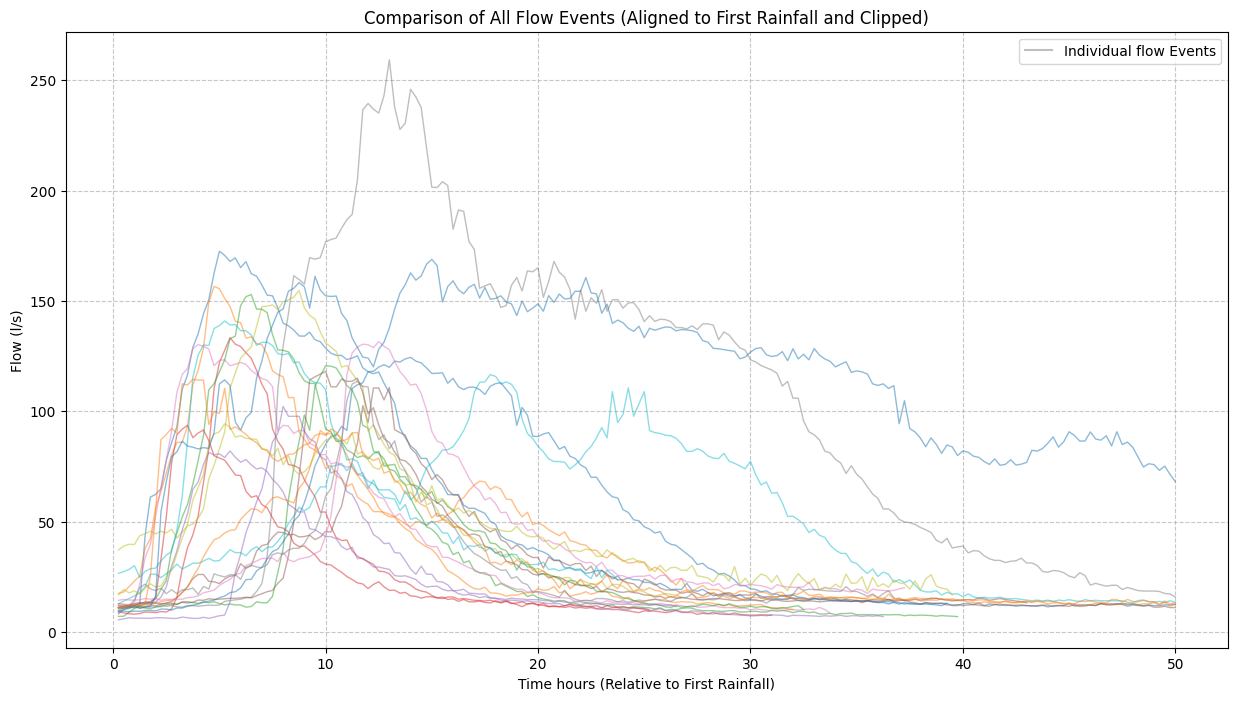

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events_clipped.columns if col.endswith('_Flow')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain. Time is a time index and is divided by 4 to give hours.
    plt.plot(df_events_clipped['Time'] / 4, df_events_clipped[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
#plt.xlabel('Time Index (Relative to First Rainfall)')
plt.xlabel('Time hours (Relative to First Rainfall)')
plt.ylabel('Flow (l/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall and Clipped)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual flow Events')
plt.legend()

plt.show()

## Save Clipped Dataset

Exports clipped dataset:


In [ ]:
# Define the event output file path for the complete event analysis for all events
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Oak_storm_event_timeseries_all_clipped_23events.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Bollin_storm_event_timeseries_all_clipped.csv'
# Define the event output file path for the complete event analysis for events before NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Bollin_storm_event_timeseries_all_clipped_before.csv'
# Define the event output file path for the complete event analysis for events after NFM
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Bollin_storm_event_timeseries_all_clipped_after.csv'

# Save the adjusted event_peak_df to CSV
df_events_clipped.to_csv(final_output_path, index=False)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Oak_storm_event_timeseries_all_clipped_23events.csv


# Split Clipped Events into Winter and Summer events

In [ ]:
import pandas as pd

# Ensure duration_df exists in globals
if 'duration_df' in globals():
    # Make a copy to avoid SettingWithCopyWarning if duration_df was a slice
    events_summary_df = duration_df.copy()

    # Convert 'Start Time' to datetime for seasonal logic
    events_summary_df['Start Time'] = pd.to_datetime(events_summary_df['Start Time'])

    # Winter Season: Oct (10), Nov (11), Dec (12), Jan (1), Feb (2), Mar (3)
    # Note: April 1 is included in Summer Season as per request

    def get_season(dt):
        if dt.month >= 10 or dt.month < 4 or (dt.month == 4 and dt.day == 1):
            return 'Winter'
        else:
            return 'Summer'

    # Apply seasonal categorization to the events_summary_df
    events_summary_df['Season'] = events_summary_df['Start Time'].apply(get_season)

    # Create Winter and Summer dataframes from the events_summary_df
    winter_season_df = events_summary_df[events_summary_df['Season'] == 'Winter'].copy()
    summer_season_df = events_summary_df[events_summary_df['Season'] == 'Summer'].copy()

    # Define paths
    winter_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_winter_season_events_clip_flag_23events.csv'
    summer_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_summer_season_events_clip_flag_23events.csv'
   # winter_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_winter_season_events_clip_flag.csv'
   #summer_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_summer_season_events_clip_flag.csv'

    # Save files
    winter_season_df.to_csv(winter_path, index=False)
    summer_season_df.to_csv(summer_path, index=False)

    print(f"Wet Season events identified: {len(winter_season_df)}")
    print(f"Dry Season events identified: {len(summer_season_df)}")

    print(f"Saved Wet Season data to: {winter_path}")
    print(f"Saved Dry Season data to: {summer_path}")

    print('\nWinter Season DataFrame Head:')
    display(winter_season_df.head())

    print('\nSummer Season DataFrame Head:')
    display(summer_season_df.head())
else:
    print("Error: Required dataframe 'duration_df' not found in memory.")

Wet Season events identified: 12
Dry Season events identified: 10
Saved Wet Season data to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_winter_season_events_clip_flag_23events.csv
Saved Dry Season data to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_summer_season_events_clip_flag_23events.csv

Winter Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
5,Event006,2023-10-05 19:00:00,2023-10-08 04:45:00,57.75,Winter
6,Event007,2023-10-13 03:00:00,2023-10-14 12:30:00,33.50,Winter
7,Event008,2023-10-19 22:00:00,2023-10-22 23:15:00,73.25,Winter
8,Event009,2023-11-02 09:45:00,2023-11-03 12:15:00,26.50,Winter
9,Event010,2023-11-14 18:00:00,2023-11-17 13:00:00,67.00,Winter



Summer Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
0,Event001,2023-07-26 20:30:00,2023-07-29 06:00:00,57.50,Summer
1,Event002,2023-08-02 03:15:00,2023-08-04 06:45:00,51.50,Summer
2,Event003,2023-08-14 09:00:00,2023-08-16 01:15:00,40.25,Summer
3,Event004,2023-08-25 22:00:00,2023-08-27 05:00:00,31.00,Summer
4,Event005,2023-09-12 01:30:00,2023-09-13 13:30:00,36.00,Summer


In [ ]:
# Get the list of event names for winter and summer seasons
winter_events = winter_season_df['Event'].tolist()
summer_events = summer_season_df['Event'].tolist()

# Prepare column lists for winter and summer clipped dataframes
# Start with the 'Time' index column
winter_cols = ['Time']
summer_cols = ['Time']

# Iterate through all columns in df_events_clipped to find event-specific columns
for col in df_events_clipped.columns:
    # Extract the event identifier (e.g., 'Event001') from the column name
    # This assumes column names are like 'EventXXX_Type'
    if '_' in col:
        event_id = col.split('_')[0]
    else:
        # Skip 'Time' column as it's already added
        continue

    if event_id in winter_events:
        winter_cols.append(col)
    elif event_id in summer_events:
        summer_cols.append(col)

# Create the new DataFrames by selecting the identified columns
# Use .copy() to ensure these are independent DataFrames
df_events_clipped_winter = df_events_clipped[winter_cols].copy()
df_events_clipped_summer = df_events_clipped[summer_cols].copy()

print(f"Number of columns in winter clipped DataFrame (including 'Time'): {len(df_events_clipped_winter.columns)}")
print(f"Number of columns in summer clipped DataFrame (including 'Time'): {len(df_events_clipped_summer.columns)}")

print("\nFirst 5 rows of df_events_clipped_winter:")
display(df_events_clipped_winter.head())

print("\nFirst 5 rows of df_events_clipped_summer:")
display(df_events_clipped_summer.head())

Number of columns in winter clipped DataFrame (including 'Time'): 49
Number of columns in summer clipped DataFrame (including 'Time'): 41

First 5 rows of df_events_clipped_winter:


,Time,Event006_Time,Event006_Rain,Event006_Flow,Event006_Baseflow,Event007_Time,Event007_Rain,Event007_Flow,Event007_Baseflow,Event008_Time,...,Event015_Flow,Event015_Baseflow,Event016_Time,Event016_Rain,Event016_Flow,Event016_Baseflow,Event017_Time,Event017_Rain,Event017_Flow,Event017_Baseflow
0,1,05/10/2023 19:00,0.4,10.9,9.2,13/10/2023 03:00,0.6,8.8,7.6,19/10/2023 22:15,...,11.0,9.4,28/02/2024 17:15,0.6,12.7,7.9,13/03/2024 11:00,0.2,14.3,10.9
1,2,05/10/2023 19:15,0.2,11.1,9.2,13/10/2023 03:15,1.0,10.0,7.6,19/10/2023 22:30,...,11.4,9.4,28/02/2024 17:30,0.4,12.5,7.9,13/03/2024 11:15,0.2,14.7,10.9
2,3,05/10/2023 19:30,0.8,11.5,9.2,13/10/2023 03:30,0.6,11.2,7.6,19/10/2023 22:45,...,11.5,9.4,28/02/2024 17:45,0.2,12.2,7.9,13/03/2024 11:30,0.0,14.4,10.9
3,4,05/10/2023 19:45,1.4,11.4,9.2,13/10/2023 03:45,0.6,13.5,7.6,19/10/2023 23:00,...,11.5,9.4,28/02/2024 18:00,1.2,12.8,7.9,13/03/2024 11:45,0.4,14.4,10.9
4,5,05/10/2023 20:00,0.4,11.5,9.2,13/10/2023 04:00,0.6,21.5,7.6,19/10/2023 23:15,...,12.7,9.4,28/02/2024 18:15,1.2,13.3,7.9,13/03/2024 12:00,0.4,14.5,10.9



First 5 rows of df_events_clipped_summer:


,Time,Event001_Time,Event001_Rain,Event001_Flow,Event001_Baseflow,Event002_Time,Event002_Rain,Event002_Flow,Event002_Baseflow,Event003_Time,...,Event020_Flow,Event020_Baseflow,Event021_Time,Event021_Rain,Event021_Flow,Event021_Baseflow,Event022_Time,Event022_Rain,Event022_Flow,Event022_Baseflow
0,1,26/07/2023 20:30,1.4,11.0,9.3,02/08/2023 03:15,0.6,17.4,14.7,14/08/2023 09:45,...,26.5,20.4,22/05/2024 09:30,0.4,8.2,7.1,09/06/2024 19:15,0.2,10.7,9.0
1,2,26/07/2023 20:45,1.6,11.6,9.3,02/08/2023 03:30,1.0,18.1,14.4,14/08/2023 10:00,...,27.3,20.4,22/05/2024 09:45,0.6,10.2,7.1,09/06/2024 19:30,0.4,11.3,9.0
2,3,26/07/2023 21:00,1.2,11.9,9.3,02/08/2023 03:45,0.2,20.5,14.4,14/08/2023 10:15,...,28.3,20.4,22/05/2024 10:00,7.6,10.6,7.1,09/06/2024 19:45,0.6,12.1,9.0
3,4,26/07/2023 21:15,0.8,12.0,9.3,02/08/2023 04:00,0.2,23.0,14.4,14/08/2023 10:30,...,30.0,20.4,22/05/2024 10:15,1.0,11.9,7.1,09/06/2024 20:00,0.6,11.6,9.0
4,5,26/07/2023 21:30,0.4,12.6,9.3,02/08/2023 04:15,0.2,25.3,14.2,14/08/2023 10:45,...,24.7,20.4,22/05/2024 10:30,0.8,10.6,7.1,09/06/2024 20:15,1.2,12.3,9.0


In [ ]:
winter_season_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_winter_season_events_clip_flag_23events.csv'
summer_season_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_summer_season_events_clip_flag_23events.csv'

#winter_season_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_winter_season_events_clip_flag.csv'
#summer_season_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_summer_season_events_clip_flag.csv'

winter_season_df = pd.read_csv(winter_season_path)
summer_season_df = pd.read_csv(summer_season_path)

print(f'Loaded winter season events from: {winter_season_path}')
print(f'Loaded summer season events from: {summer_season_path}')

print('\nWinter Season DataFrame Head:')
display(winter_season_df.head())

print('\nSummer Season DataFrame Head:')
display(summer_season_df.head())

Loaded winter season events from: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_winter_season_events_clip_flag_23events.csv
Loaded summer season events from: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_summer_season_events_clip_flag_23events.csv

Winter Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
0,Event006,2023-10-05 19:00:00,2023-10-08 04:45:00,57.75,Winter
1,Event007,2023-10-13 03:00:00,2023-10-14 12:30:00,33.50,Winter
2,Event008,2023-10-19 22:00:00,2023-10-22 23:15:00,73.25,Winter
3,Event009,2023-11-02 09:45:00,2023-11-03 12:15:00,26.50,Winter
4,Event010,2023-11-14 18:00:00,2023-11-17 13:00:00,67.00,Winter



Summer Season DataFrame Head:


,Event,Start Time,End Time,Duration (hours),Season
0,Event001,2023-07-26 20:30:00,2023-07-29 06:00:00,57.50,Summer
1,Event002,2023-08-02 03:15:00,2023-08-04 06:45:00,51.50,Summer
2,Event003,2023-08-14 09:00:00,2023-08-16 01:15:00,40.25,Summer
3,Event004,2023-08-25 22:00:00,2023-08-27 05:00:00,31.00,Summer
4,Event005,2023-09-12 01:30:00,2023-09-13 13:30:00,36.00,Summer


In [ ]:
# Define output paths for the new seasonal clipped dataframes for all events
winter_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_events_clipped_winter_details_23events.csv'
summer_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_events_clipped_summer_details_23events.csv'

#winter_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_winter_details.csv'
#summer_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_summer_details.csv'

# Define output paths for the new seasonal clipped dataframes before NFM
#winter_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_winter_details_before.csv'
#summer_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_summer_details_before.csv'

# Define output paths for the new seasonal clipped dataframes after NFM
#winter_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_winter_details_after.csv'
#summer_clipped_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Bollin_events_clipped_summer_details_after.csv'

# Save the seasonal clipped dataframes to CSV
df_events_clipped_winter.to_csv(winter_clipped_output_path, index=False)
df_events_clipped_summer.to_csv(summer_clipped_output_path, index=False)

print(f"Successfully saved winter clipped events to: {winter_clipped_output_path}")
print(f"Successfully saved summer clipped events to: {summer_clipped_output_path}")

Successfully saved winter clipped events to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_events_clipped_winter_details_23events.csv
Successfully saved summer clipped events to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Clipped/Oak_events_clipped_summer_details_23events.csv
